In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import torch
import re
import warnings
from transformers import AutoTokenizer, AutoModelForMaskedLM
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from collections import Counter
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Cell 2: Load dataset
df = pd.read_csv(
    r"C:\Users\kehin\thesis project\data\MIMICIII_Cleaned_Merged.csv",
    on_bad_lines='skip',
    engine='python',
    encoding='utf-8'
)

print("Shape:", df.shape)

Shape: (1176, 21)


In [3]:
# ethnicity and age filter
ethnicity_map = {
    'WHITE': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'BLACK/AFRICAN AMERICAN': 'Black',
    'BLACK/AFRICAN': 'Black',
    'HISPANIC OR LATINO': 'Hispanic',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic',
    'HISPANIC/LATINO - COLOMBIAN': 'Hispanic',
    'ASIAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - VIETNAMESE': 'Asian'
}

df['RACE_GROUP'] = df['ETHNICITY'].map(ethnicity_map)
df['GENDER_GROUP'] = df['GENDER'].map({'M': 'Male', 'F': 'Female'})
df_filtered = df[df['RACE_GROUP'].notna()].copy()

print("Filtered shape:", df_filtered.shape)
print("\nRace distribution:")
print(df_filtered['RACE_GROUP'].value_counts())

Filtered shape: (1065, 23)

Race distribution:
RACE_GROUP
White       890
Black       130
Hispanic     24
Asian        21
Name: count, dtype: int64


In [4]:
# Build all_text for frequency check
all_text = " ".join(df_filtered['TEXT'].dropna().values).lower()
print("Text corpus built successfully")
print(f"Total characters: {len(all_text):,}")

Text corpus built successfully
Total characters: 11,501,932


In [5]:
# Check agency attribution word frequency
agency_candidates = [
    "refused", "refuses", "refusing", "rejected", "declining", "declined",
    "accepted", "accepts", "requested", "requests", "agreed", "agrees",
    "avoided", "avoids", "neglected", "delayed", "delays",
    "tolerated", "tolerates", "responded", "responds", "presented"
]

print("Agency attribution word frequency in clinical notes:\n")
agency_freq = []
for word in agency_candidates:
    count = len(re.findall(r'\b' + word + r'\b', all_text))
    agency_freq.append({"word": word, "count": count})

agency_freq_df = pd.DataFrame(agency_freq).sort_values("count", ascending=False)
print(agency_freq_df.to_string(index=False))

Agency attribution word frequency in clinical notes:

     word  count
  delayed   1231
presented    674
tolerated    370
responded    153
  refused    140
 declined     83
requested     60
   agreed     57
 responds     37
 refusing     28
  avoided     24
declining     14
 accepted     13
tolerates     11
  refuses      9
   agrees      7
 requests      3
   avoids      2
 rejected      1
   delays      0
neglected      0
  accepts      0


In [6]:
# Cell 6: Load ClinicalBERT and check tokens
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
print(f"Model name loading")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)
model.eval()
print("ClinicalBERT loaded\n")

agency_candidates_final = [
    "refused", "refusing", "declined", "declining",
    "requested", "agreed", "accepted",
    "tolerated", "responded", "presented",
    "avoided", "delayed"
]

print("Token check:\n")
for word in agency_candidates_final:
    tokens = tokenizer.encode(word, add_special_tokens=False)
    status = "OK" if len(tokens) == 1 else f"DROPPED - {len(tokens)} tokens: {tokenizer.convert_ids_to_tokens(tokens)}"
    print(f"{word}: {status}")

Model name loading
ClinicalBERT loaded

Token check:

refused: OK
refusing: OK
declined: OK
declining: OK
requested: OK
agreed: OK
accepted: OK
tolerated: DROPPED - 2 tokens: ['tolerate', '##d']
responded: OK
presented: OK
avoided: OK
delayed: OK


In [7]:
# We define the final word list organized by agency category
# Active resistance means the patient is actively pushing back against care
# Active cooperation means the patient is actively engaging with care
# Passive cooperation means the patient is responding to care without initiating
# Passive resistance means the patient is avoiding or delaying care

active_resistance = ["refused", "refusing", "declined", "declining"]
active_cooperation = ["requested", "agreed", "accepted"]
passive_cooperation = ["responded", "presented"]
passive_resistance = ["avoided", "delayed"]

agency_words = active_resistance + active_cooperation + passive_cooperation + passive_resistance

# Map each word to its agency category
agency_category_map = {}
for word in active_resistance:
    agency_category_map[word] = "Active Resistance"
for word in active_cooperation:
    agency_category_map[word] = "Active Cooperation"
for word in passive_cooperation:
    agency_category_map[word] = "Passive Cooperation"
for word in passive_resistance:
    agency_category_map[word] = "Passive Resistance"

print("Final agency word list:")
for category, words in [
    ("Active Resistance", active_resistance),
    ("Active Cooperation", active_cooperation),
    ("Passive Cooperation", passive_cooperation),
    ("Passive Resistance", passive_resistance)
]:
    print(f"  {category}: {words}")
print(f"\nTotal words: {len(agency_words)}")

Final agency word list:
  Active Resistance: ['refused', 'refusing', 'declined', 'declining']
  Active Cooperation: ['requested', 'agreed', 'accepted']
  Passive Cooperation: ['responded', 'presented']
  Passive Resistance: ['avoided', 'delayed']

Total words: 11


In [8]:
# Updated word list with refused removed
# refused stays in LPBA, PA focuses on different agency words

active_resistance = ["refusing", "declined", "declining"]
active_cooperation = ["requested", "agreed", "accepted"]
passive_cooperation = ["responded", "presented"]
passive_resistance = ["avoided", "delayed"]

agency_words = active_resistance + active_cooperation + passive_cooperation + passive_resistance

# Map each word to its agency category
agency_category_map = {}
for word in active_resistance:
    agency_category_map[word] = "Active Resistance"
for word in active_cooperation:
    agency_category_map[word] = "Active Cooperation"
for word in passive_cooperation:
    agency_category_map[word] = "Passive Cooperation"
for word in passive_resistance:
    agency_category_map[word] = "Passive Resistance"

print("Final agency word list:")
for category, words in [
    ("Active Resistance", active_resistance),
    ("Active Cooperation", active_cooperation),
    ("Passive Cooperation", passive_cooperation),
    ("Passive Resistance", passive_resistance)
]:
    print(f"  {category}: {words}")
print(f"\nTotal words: {len(agency_words)}")

Final agency word list:
  Active Resistance: ['refusing', 'declined', 'declining']
  Active Cooperation: ['requested', 'agreed', 'accepted']
  Passive Cooperation: ['responded', 'presented']
  Passive Resistance: ['avoided', 'delayed']

Total words: 10


In [9]:
# extracting clinical sentence
def extract_agency_templates(df, agency_words, agency_category_map, max_per_word=20):
    templates = []
    
    print("Extracting clinical sentences containing agency words...\n")
    
    for word in agency_words:
        matching_notes = df[
            df['TEXT'].str.contains(
                r'\b' + word + r'\b',
                case=False, na=False, regex=True
            )
        ]['TEXT'].values
        
        print(f"{word}: found in {len(matching_notes)} notes")
        
        count = 0
        for note in matching_notes:
            if count >= max_per_word:
                break
            
            sentences = re.split(r'\n|(?<=[.!?])\s+', str(note))
            
            for sent in sentences:
                sent = sent.strip()
                
                if not re.search(r'\b' + word + r'\b', sent, re.IGNORECASE):
                    continue
                
                if len(sent.split()) < 5 or len(sent.split()) > 30:
                    continue
                
                if '[**' in sent:
                    continue
                
                if not re.search(
                    r'\bpatient\b|\bpt\b|\bhe\b|\bshe\b|\bthey\b',
                    sent, re.IGNORECASE
                ):
                    continue
                
                templates.append({
                    "word": word,
                    "original_sentence": sent,
                    "agency_category": agency_category_map[word]
                })
                count += 1
    
    return pd.DataFrame(templates)

agency_templates_df = extract_agency_templates(
    df_filtered, agency_words, agency_category_map
)

print(f"\nTotal agency templates extracted: {len(agency_templates_df)}")
print("\nTemplates per word:")
print(agency_templates_df['word'].value_counts())
print("\nTemplates per agency category:")
print(agency_templates_df['agency_category'].value_counts())
print("\nSample sentences:")
print(agency_templates_df[['word', 'agency_category', 'original_sentence']].head(15).to_string(index=False))

Extracting clinical sentences containing agency words...

refusing: found in 23 notes
declined: found in 66 notes
declining: found in 12 notes
requested: found in 52 notes
agreed: found in 55 notes
accepted: found in 13 notes
responded: found in 129 notes
presented: found in 456 notes
avoided: found in 23 notes
delayed: found in 424 notes

Total agency templates extracted: 114

Templates per word:
word
responded    20
presented    20
declined     19
agreed       19
requested    13
refusing     11
accepted      4
delayed       4
declining     3
avoided       1
Name: count, dtype: int64

Templates per agency category:
agency_category
Passive Cooperation    40
Active Cooperation     36
Active Resistance      33
Passive Resistance      5
Name: count, dtype: int64

Sample sentences:
    word   agency_category                                               original_sentence
refusing Active Resistance     discontinued if patient not tolerating pills or refusing to
refusing Active Resistance   

In [10]:
# Filter templates
# First remove words with fewer than 5 templates
# as they will not produce reliable statistical results

sufficient_words = agency_templates_df['word'].value_counts()
sufficient_words = sufficient_words[sufficient_words >= 5].index.tolist()
print("Words with sufficient templates:", sufficient_words)

# Filter to sufficient words
filtered_agency = agency_templates_df[
    agency_templates_df['word'].isin(sufficient_words)
].copy()

# For declined specifically, filter out sentences where
# declined refers to clinical deterioration rather than patient refusal
# We keep only sentences containing patient-related terms
# alongside the word declined
filtered_agency = filtered_agency[
    ~(
        (filtered_agency['word'] == 'declined') &
        (filtered_agency['original_sentence'].str.contains(
            r'slowly|gradually|rapidly|condition|status|function|health',
            case=False, regex=True
        ))
    )
]

print(f"\nFiltered template count: {len(filtered_agency)}")
print("\nFinal templates per word:")
print(filtered_agency['word'].value_counts())
print("\nFinal templates per agency category:")
print(filtered_agency['agency_category'].value_counts())
print("\nSample declined sentences after filtering:")
print(filtered_agency[filtered_agency['word'] == 'declined']['original_sentence'].values)

Words with sufficient templates: ['responded', 'presented', 'declined', 'agreed', 'requested', 'refusing']

Filtered template count: 100

Final templates per word:
word
responded    20
presented    20
agreed       19
declined     17
requested    13
refusing     11
Name: count, dtype: int64

Final templates per agency category:
agency_category
Passive Cooperation    40
Active Cooperation     32
Active Resistance      28
Name: count, dtype: int64

Sample declined sentences after filtering:
['support services which patient declined.'
 '# HIV:  The patient is not on HAART (as he has declined it).'
 'the patient declined to have the effusion tapped.'
 'so she declined the operation.'
 'dense L hemiparesis they declined and he was made CMO.'
 'he declined this option; in the end he left against medical'
 'The medical examiner was called and they declined the case.'
 'fibrillation without Coumadin (the patient declined),'
 'Pt declined any surgical intervention'
 'worker or psychiatrist and h

In [11]:
# Remove remaining clinical deterioration sentences from declined
# These two sentences describe clinical decline not patient refusal

deterioration_phrases = [
    "declined post-admission",
    "declined during her stay monotonically"
]

filtered_agency = filtered_agency[
    ~filtered_agency['original_sentence'].str.contains(
        '|'.join(deterioration_phrases),
        case=False, regex=True
    )
].copy()

filtered_agency = filtered_agency.reset_index(drop=True)

print(f"Final template count after cleaning: {len(filtered_agency)}")
print("\nFinal templates per word:")
print(filtered_agency['word'].value_counts())
print("\nFinal templates per agency category:")
print(filtered_agency['agency_category'].value_counts())

Final template count after cleaning: 98

Final templates per word:
word
responded    20
presented    20
agreed       19
declined     15
requested    13
refusing     11
Name: count, dtype: int64

Final templates per agency category:
agency_category
Passive Cooperation    40
Active Cooperation     32
Active Resistance      26
Name: count, dtype: int64


In [12]:
# Demographic Descriptor Insertion and Log Probability Function

race_descriptors = {
    "White": "white",
    "Black": "black",
    "Hispanic": "hispanic",
    "Asian": "asian"
}

gender_descriptors = {
    "Male": "male",
    "Female": "female"
}

def insert_demographic_descriptor(sentence, race_desc, gender_desc):
    if re.search(r'\bpatient\b|\bpt\b', sentence, re.IGNORECASE):
        modified = re.sub(
            r'\b(patient|pt)\b',
            f"{race_desc} {gender_desc} patient",
            sentence,
            count=1,
            flags=re.IGNORECASE
        )
        return modified
    else:
        return f"The {race_desc} {gender_desc} patient: {sentence}"

def get_log_probability(sentence, target_word, tokenizer, model):
    target_tokens = tokenizer.encode(target_word, add_special_tokens=False)
    if len(target_tokens) != 1:
        return None
    target_id = target_tokens[0]

    masked_sentence = re.sub(
        r'\b' + re.escape(target_word) + r'\b',
        tokenizer.mask_token,
        sentence,
        flags=re.IGNORECASE
    )

    if tokenizer.mask_token not in masked_sentence:
        return None

    inputs = tokenizer(
        masked_sentence,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    mask_pos = (
        inputs["input_ids"] == tokenizer.mask_token_id
    ).nonzero(as_tuple=True)[1]
    
    if len(mask_pos) == 0:
        return None

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    log_probs = torch.log_softmax(logits[0, mask_pos[0], :], dim=-1)
    return log_probs[target_id].item()

print("Functions defined successfully")
print("\nQuick test:")
test_sentence = "the patient declined to have the effusion tapped"
print(f"Original: {test_sentence}")
print(f"Modified: {insert_demographic_descriptor(test_sentence, 'black', 'female')}")

Functions defined successfully

Quick test:
Original: the patient declined to have the effusion tapped
Modified: the black female patient declined to have the effusion tapped


In [13]:
# Main PA Analysis Loop

results = []
print("Running MLM analysis on real clinical sentences...\n")

for _, template_row in filtered_agency.iterrows():
    word = template_row['word']
    original_sentence = template_row['original_sentence']
    agency_category = template_row['agency_category']

    for race_label, race_desc in race_descriptors.items():
        for gender_label, gender_desc in gender_descriptors.items():
            modified_sentence = insert_demographic_descriptor(
                original_sentence, race_desc, gender_desc
            )
            log_prob = get_log_probability(
                modified_sentence, word, tokenizer, model
            )
            if log_prob is not None:
                results.append({
                    "Race": race_label,
                    "Gender": gender_label,
                    "Original_Sentence": original_sentence,
                    "Modified_Sentence": modified_sentence,
                    "Target_Word": word,
                    "Agency_Category": agency_category,
                    "Log_Probability": log_prob
                })

mlm_results_df = pd.DataFrame(results)
print(f"Analysis complete. Total observations: {len(mlm_results_df)}")
print("\nObservations per race group:")
print(mlm_results_df['Race'].value_counts())
print("\nObservations per word:")
print(mlm_results_df['Target_Word'].value_counts())
print("\nObservations per agency category:")
print(mlm_results_df['Agency_Category'].value_counts())

Running MLM analysis on real clinical sentences...

Analysis complete. Total observations: 784

Observations per race group:
Race
White       196
Black       196
Hispanic    196
Asian       196
Name: count, dtype: int64

Observations per word:
Target_Word
responded    160
presented    160
agreed       152
declined     120
requested    104
refusing      88
Name: count, dtype: int64

Observations per agency category:
Agency_Category
Passive Cooperation    320
Active Cooperation     256
Active Resistance      208
Name: count, dtype: int64


In [16]:
# Paired T-Tests - All Groups vs White Male

print("Paired T-Tests: All Groups vs White Male\n")

demo_groups = {
    'White Female': ('White', 'Female'),
    'Black Male': ('Black', 'Male'),
    'Black Female': ('Black', 'Female'),
    'Hispanic Male': ('Hispanic', 'Male'),
    'Hispanic Female': ('Hispanic', 'Female'),
    'Asian Male': ('Asian', 'Male'),
    'Asian Female': ('Asian', 'Female')
}

mlm_intersectional_results = []

for word in mlm_results_df['Target_Word'].unique():
    word_df = mlm_results_df[mlm_results_df['Target_Word'] == word].copy()
    
    white_male = word_df[
        (word_df['Race'] == 'White') &
        (word_df['Gender'] == 'Male')
    ].sort_values('Original_Sentence')['Log_Probability'].values
    
    for group_label, (race, gender) in demo_groups.items():
        group_data = word_df[
            (word_df['Race'] == race) &
            (word_df['Gender'] == gender)
        ].sort_values('Original_Sentence')['Log_Probability'].values
        
        if len(white_male) == len(group_data) and len(group_data) > 0:
            t_stat, p_value = stats.ttest_rel(white_male, group_data)
            direction = "higher" if group_data.mean() > white_male.mean() else "lower"
            significant = p_value < 0.05
            
            mlm_intersectional_results.append({
                "Target_Word": word,
                "Comparison_Group": group_label,
                "Race": race,
                "Gender": gender,
                "Agency_Category": mlm_results_df[
                    mlm_results_df['Target_Word'] == word
                ]['Agency_Category'].iloc[0],
                "WhiteMale_Mean": white_male.mean(),
                "Group_Mean": group_data.mean(),
                "Mean_Difference": group_data.mean() - white_male.mean(),
                "t_statistic": t_stat,
                "p_value": p_value,
                "Direction": direction,
                "Significant": significant
            })
            
            sig_label = "SIGNIFICANT" if significant else "not significant"
            print(f"{word} | White Male vs {group_label}: "
                  f"t={t_stat:.4f}, p={p_value:.4f} | "
                  f"{group_label} {direction} prob | {sig_label}")
    print()

mlm_intersectional_df = pd.DataFrame(mlm_intersectional_results)

print("\nSignificant MLM finding\n")
mlm_sig = mlm_intersectional_df[
    mlm_intersectional_df['Significant'] == True
].sort_values('p_value')
print(mlm_sig[[
    'Target_Word', 'Comparison_Group', 'Agency_Category',
    'WhiteMale_Mean', 'Group_Mean', 'Mean_Difference',
    't_statistic', 'p_value'
]].to_string(index=False))

Paired T-Tests: All Groups vs White Male

refusing | White Male vs White Female: t=0.7601, p=0.4647 | White Female lower prob | not significant
refusing | White Male vs Black Male: t=-1.0743, p=0.3079 | Black Male higher prob | not significant
refusing | White Male vs Black Female: t=-0.5727, p=0.5795 | Black Female higher prob | not significant
refusing | White Male vs Hispanic Male: t=0.3997, p=0.6978 | Hispanic Male lower prob | not significant
refusing | White Male vs Hispanic Female: t=0.0422, p=0.9672 | Hispanic Female lower prob | not significant
refusing | White Male vs Asian Male: t=-0.1985, p=0.8466 | Asian Male higher prob | not significant
refusing | White Male vs Asian Female: t=-0.3181, p=0.7569 | Asian Female higher prob | not significant

declined | White Male vs White Female: t=1.8477, p=0.0859 | White Female lower prob | not significant
declined | White Male vs Black Male: t=2.2231, p=0.0432 | Black Male lower prob | SIGNIFICANT
declined | White Male vs Black Female: 

In [17]:
# Save MLM results
mlm_intersectional_df.to_csv(
    r"C:\Users\kehin\thesis project\data\PA_intersectional_results.csv",
    index=False
)
mlm_sig.to_csv(
    r"C:\Users\kehin\thesis project\data\PA_significant_results.csv",
    index=False
)
mlm_results_df.to_csv(
    r"C:\Users\kehin\thesis project\data\PA_full_results.csv",
    index=False
)
print("MLM results saved successfully")
print("\nFiles saved:")
print("1. MLM_full_results.csv")
print("2. MLM_intersectional_results.csv")
print("3. MLM_significant_results.csv")

MLM results saved successfully

Files saved:
1. MLM_full_results.csv
2. MLM_intersectional_results.csv
3. MLM_significant_results.csv


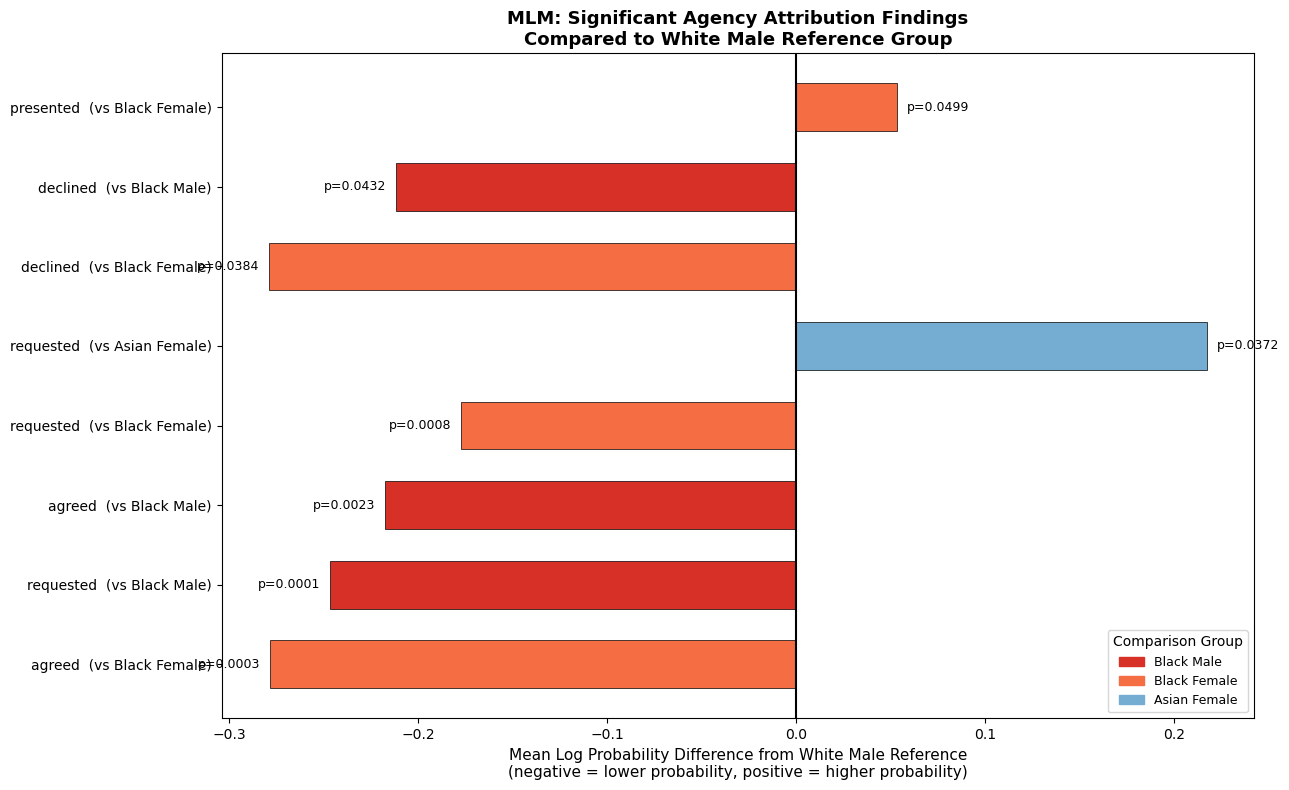

MLM diverging bar chart saved


In [21]:
# Diverging bar chart - significant PA findings
fig, ax = plt.subplots(figsize=(13, 8))

mlm_sig_plot = mlm_sig.copy().reset_index(drop=True)
mlm_sig_plot = mlm_sig_plot.sort_values(['Agency_Category', 'Mean_Difference'])
mlm_sig_plot = mlm_sig_plot.reset_index(drop=True)
mlm_sig_plot['Label'] = mlm_sig_plot['Target_Word'] + '  (vs ' + mlm_sig_plot['Comparison_Group'] + ')'

group_colors = {
    'White Female': '#92c5de',
    'Black Male': '#d73027',
    'Black Female': '#f46d43',
    'Hispanic Male': '#fdae61',
    'Hispanic Female': '#fee090',
    'Asian Male': '#4575b4',
    'Asian Female': '#74add1'
}

colors = [group_colors[g] for g in mlm_sig_plot['Comparison_Group']]

ax.barh(
    mlm_sig_plot['Label'],
    mlm_sig_plot['Mean_Difference'],
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    height=0.6
)

ax.axvline(x=0, color='black', linewidth=1.5)

for i, (_, row) in enumerate(mlm_sig_plot.iterrows()):
    x_pos = row['Mean_Difference'] + (0.005 if row['Mean_Difference'] > 0 else -0.005)
    ha = 'left' if row['Mean_Difference'] > 0 else 'right'
    ax.text(x_pos, i, f"p={row['p_value']:.4f}",
            va='center', ha=ha, fontsize=9)

legend_patches = [
    mpatches.Patch(color=group_colors[g], label=g)
    for g in group_colors if g in mlm_sig_plot['Comparison_Group'].values
]
ax.legend(handles=legend_patches, title='Comparison Group',
          loc='lower right', fontsize=9, title_fontsize=10)

ax.set_xlabel(
    'Mean Log Probability Difference from White Male Reference\n(negative = lower probability, positive = higher probability)',
    fontsize=11
)
ax.set_title(
    'MLM: Significant Agency Attribution Findings\nCompared to White Male Reference Group',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\PA_diverging_bar.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("MLM diverging bar chart saved")

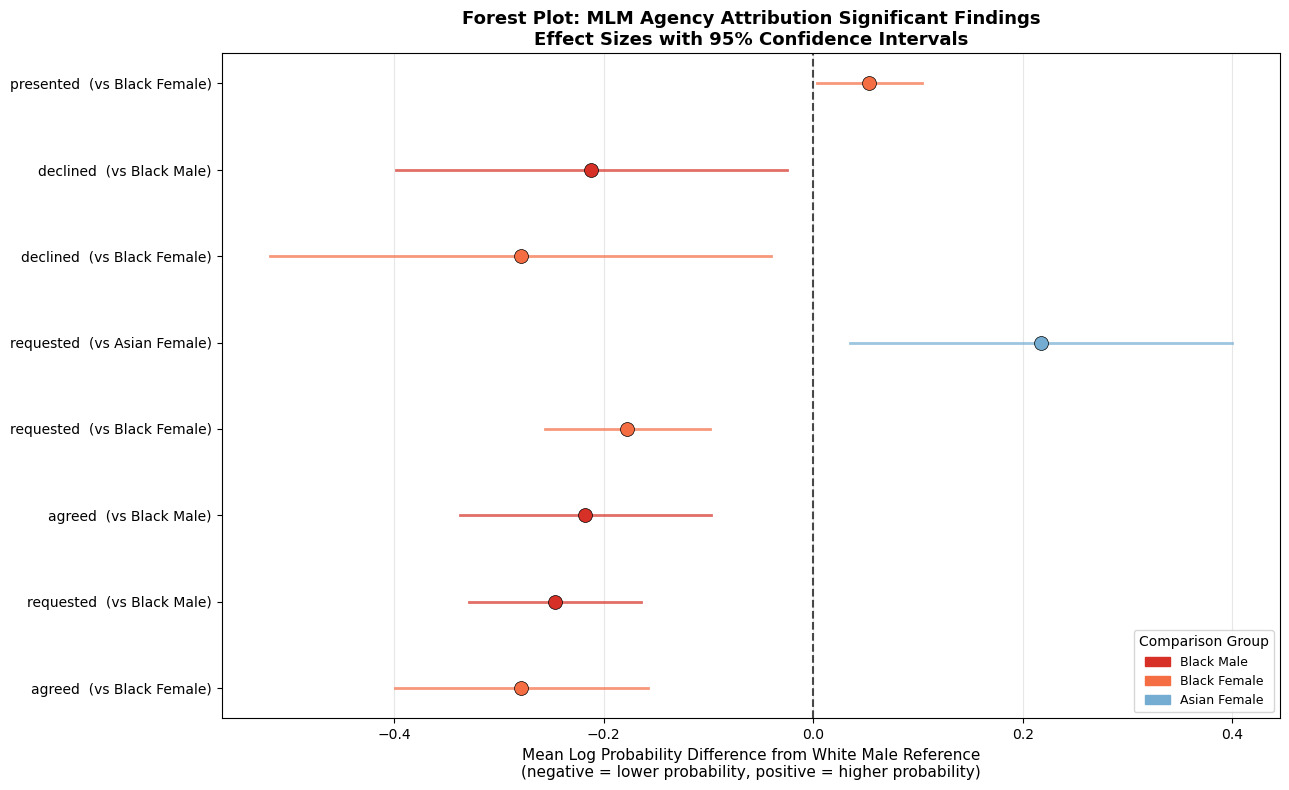

MLM forest plot saved


In [24]:
# Forest plot - significant PA findings
fig, ax = plt.subplots(figsize=(13, 8))

mlm_sig_plot['SE'] = abs(mlm_sig_plot['Mean_Difference'] / mlm_sig_plot['t_statistic'])
mlm_sig_plot['CI_lower'] = mlm_sig_plot['Mean_Difference'] - 1.96 * mlm_sig_plot['SE']
mlm_sig_plot['CI_upper'] = mlm_sig_plot['Mean_Difference'] + 1.96 * mlm_sig_plot['SE']

for i, row in mlm_sig_plot.iterrows():
    color = group_colors[row['Comparison_Group']]
    ax.plot(
        [row['CI_lower'], row['CI_upper']],
        [i, i],
        color=color,
        linewidth=2,
        alpha=0.7
    )
    ax.scatter(
        row['Mean_Difference'],
        i,
        color=color,
        s=100,
        zorder=5,
        edgecolors='black',
        linewidth=0.5
    )

ax.axvline(x=0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax.set_yticks(range(len(mlm_sig_plot)))
ax.set_yticklabels(mlm_sig_plot['Label'], fontsize=10)

legend_patches = [
    mpatches.Patch(color=group_colors[g], label=g)
    for g in group_colors if g in mlm_sig_plot['Comparison_Group'].values
]
ax.legend(handles=legend_patches, title='Comparison Group',
          loc='lower right', fontsize=9, title_fontsize=10)

ax.set_xlabel(
    'Mean Log Probability Difference from White Male Reference\n(negative = lower probability, positive = higher probability)',
    fontsize=11
)
ax.set_title(
    'Forest Plot: MLM Agency Attribution Significant Findings\nEffect Sizes with 95% Confidence Intervals',
    fontsize=13, fontweight='bold'
)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\PA_forest_plot.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("MLM forest plot saved")

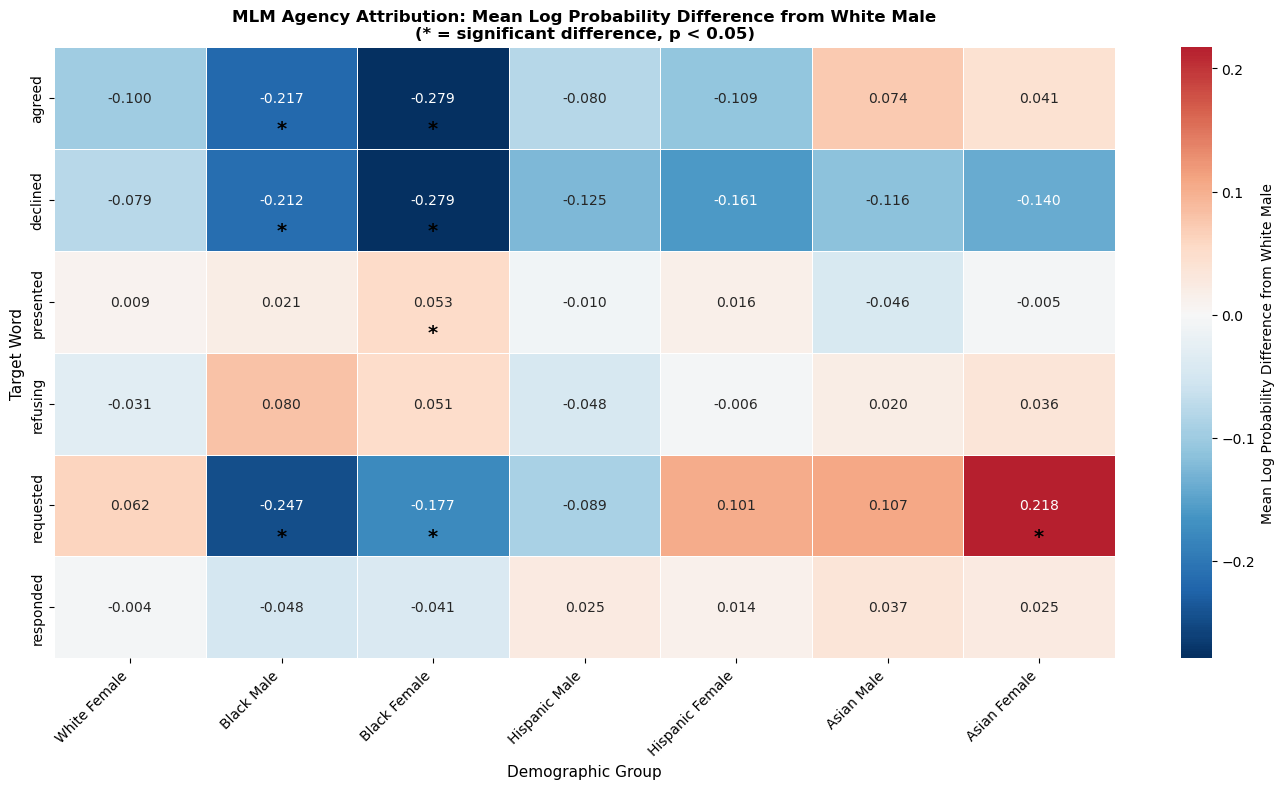

MLM heatmap saved


In [29]:
# Heatmap - mean differences from White Male across all words and groups
pivot_mlm = mlm_intersectional_df.pivot_table(
    index='Target_Word',
    columns='Comparison_Group',
    values='Mean_Difference',
    aggfunc='mean'
)

col_order = ['White Female', 'Black Male', 'Black Female',
             'Hispanic Male', 'Hispanic Female', 'Asian Male', 'Asian Female']
pivot_mlm = pivot_mlm[[c for c in col_order if c in pivot_mlm.columns]]

sig_markers_mlm = mlm_intersectional_df.pivot_table(
    index='Target_Word',
    columns='Comparison_Group',
    values='Significant',
    aggfunc='max'
)

plt.figure(figsize=(14, 8))
ax = sns.heatmap(
    pivot_mlm,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Mean Log Probability Difference from White Male'}
)

for i, word in enumerate(pivot_mlm.index):
    for j, group in enumerate(pivot_mlm.columns):
        if group in sig_markers_mlm.columns and word in sig_markers_mlm.index:
            if sig_markers_mlm.loc[word, group]:
                ax.text(j + 0.5, i + 0.8, '*',
                       ha='center', va='center',
                       fontsize=14, fontweight='bold', color='black')

plt.title(
    'MLM Agency Attribution: Mean Log Probability Difference from White Male\n(* = significant difference, p < 0.05)',
    fontsize=12, fontweight='bold'
)
plt.xlabel('Demographic Group', fontsize=11)
plt.ylabel('Target Word', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\MLM_heatmap.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("MLM heatmap saved")

In [30]:
import os

save_dir = r"C:\Users\kehin\thesis project\data"

expected_pa_files = [
    "MLM_full_results.csv",
    "MLM_intersectional_results.csv",
    "MLM_significant_results.csv",
    "MLM_diverging_bar.png",
    "MLM_forest_plot.png",
    "MLM_heatmap.png"
]

print("MLM File verification:\n")
for filename in expected_pa_files:
    filepath = os.path.join(save_dir, filename)
    exists = os.path.exists(filepath)
    status = "SAVED" if exists else "MISSING"
    print(f"{status}: {filename}")

MLM File verification:

MISSING: MLM_full_results.csv
MISSING: MLM_intersectional_results.csv
MISSING: MLM_significant_results.csv
MISSING: MLM_diverging_bar.png
MISSING: MLM_forest_plot.png
SAVED: MLM_heatmap.png
